In [2]:
from nilearn import image
import numpy as np
import os.path as op
import pandas as pd
from nilearn.glm.first_level import make_first_level_design_matrix, compute_regressor
import glob
from scipy import io
import os
from glmsingle import GLM_single
import argparse
import nibabel as nib

In [3]:
subject = 1
runs = 6
bids_folder = "/mnt/d/data/ds-mlearn"
space = "MNI152NLin2009cAsym"

data = []
for run in range(1,runs+1):
        fn = op.join(
            bids_folder,
            "derivatives",
            "fmriprep",
            f"sub-{subject:02d}",
            "func",
            f"sub-{subject:02d}_task-learn_run-{run}_space-{space}_desc-preproc_bold.nii",
        )

        data.append(nib.load(fn))

In [4]:
regressors_all = []

for run in range(1,runs+1):

    confounds = pd.read_csv(
        f"/mnt/d/data/ds-mlearn/derivatives/fmriprep/sub-{subject:02d}/func/sub-{subject:02d}_task-learn_run-{run}_desc-confounds_timeseries.tsv",
        delimiter="\t",
    )

    confounds = confounds.loc[
        :,
        [
            "trans_x",
            "trans_y",
            "trans_z",
            "rot_x",
            "rot_y",
            "rot_z",
            "a_comp_cor_00",
            "a_comp_cor_01",
            "a_comp_cor_02",
            "a_comp_cor_03",
            "a_comp_cor_04",
        ],
    ]

    physio_path = f"/mnt/d/data/ds-mlearn/derivatives/fmriprep/sub-{subject:02d}/beh/physio/RegPhysio_sub-{subject:02d}_run_{run}.mat"
    fn3 = glob.glob(physio_path)
    assert len(fn3) == 1
    fn3 = fn3[0]

    physio = io.loadmat(fn3, simplify_cells=True)["physio"]["model"]
    physio = pd.DataFrame(
        data=physio["R"],
        columns=physio["R_column_names"],
    )
    physio.columns = pd.MultiIndex.from_arrays([physio.columns, physio.columns.to_series().groupby(physio.columns).cumcount().astype(str)]).map('_'.join)
    regressors = pd.concat([confounds, physio], axis=1)
    
    regressors_all.append(regressors)

In [80]:
regressors_all[0]

,trans_x,trans_y,trans_z,rot_x,rot_y,rot_z,a_comp_cor_00,a_comp_cor_01,a_comp_cor_02,a_comp_cor_03,...,RETROICOR (respiratory)_2,RETROICOR (respiratory)_3,RETROICOR (respiratory)_4,RETROICOR (respiratory)_5,RETROICOR (respiratory)_6,RETROICOR (respiratory)_7,RETROICOR (multiplicative)_0,RETROICOR (multiplicative)_1,RETROICOR (multiplicative)_2,RETROICOR (multiplicative)_3
0,0.042697,0.141707,0.133113,-0.000634,-4.184100e-04,-0.000307,0.000000,0.000000,0.000000,0.000000,...,0.779336,-0.626606,0.526952,-0.849895,0.214730,-0.976673,-0.846265,-0.532762,-0.325693,-0.945476
1,0.032894,0.063220,0.083025,-0.000433,-2.356030e-23,-0.000435,0.000000,0.000000,0.000000,0.000000,...,0.680352,0.732886,-0.330625,-0.943762,-0.074243,0.997240,-0.496503,-0.868035,-0.973967,-0.226689
2,0.021640,0.108208,0.096374,-0.000492,-7.359030e-23,-0.000435,0.000000,0.000000,0.000000,0.000000,...,0.970557,-0.240872,-0.934161,0.356852,0.883962,-0.467559,-0.655441,0.755247,-0.818060,0.575133
3,0.033791,0.053230,0.077937,0.000168,-0.000000e+00,-0.000108,0.000000,0.000000,0.000000,0.000000,...,-0.992542,0.121902,-0.182284,-0.983246,0.970280,-0.241985,-0.901857,0.432034,0.947797,-0.318875
4,0.025328,0.019489,0.055488,0.000494,-4.146940e-04,-0.000142,0.000000,0.000000,0.000000,0.000000,...,0.549992,-0.835170,-0.088020,0.996119,-0.395018,-0.918673,0.956436,-0.291943,0.769854,0.638220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,-0.073474,-0.056847,-0.097229,-0.007177,1.961890e-03,0.003375,0.083926,-0.056057,0.083903,-0.077538,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
218,-0.082771,-0.039543,-0.097305,-0.006653,2.211890e-03,0.003436,0.018809,0.068100,0.042993,0.012017,...,-0.608878,-0.793264,0.980742,-0.195306,-0.258536,0.966002,0.875334,-0.483519,-0.149413,0.988775
219,-0.081622,-0.115243,-0.189324,-0.008432,2.211890e-03,0.003375,-0.020080,-0.081735,-0.002541,0.100141,...,0.521144,0.853469,0.036880,0.999320,-0.456817,0.889561,-0.832127,0.554586,0.039664,0.999213
220,-0.090436,-0.052051,-0.139814,-0.007829,2.425570e-03,0.003715,-0.056541,-0.015824,-0.034407,-0.033172,...,0.917365,-0.398046,0.817304,-0.576206,0.683118,-0.730308,0.319805,0.947483,-0.083764,0.996486


In [5]:
frametimes = np.linspace(2.3 / 2.0, (222 - 0.5) * 2.3, 222)

In [7]:
conditions_all = []
onsets_all = []
pupil_all = []
for run in range(1, runs+1):

    blinks = pd.read_csv(op.join(bids_folder, "derivatives", "pupil_preproc", f"sub-{subject:02d}", "func", f"sub-{subject:02d}_run-{run}_blinks.tsv"), delimiter="\t")
    blinks['trial_type'] = "blink"
    conditions = blinks['trial_type'].values.tolist()
    onsets = blinks['onset'].values.tolist()
    #durations = blinks['duration'].values.tolist()

    saccades = pd.read_csv(op.join(bids_folder, "derivatives", "pupil_preproc", f"sub-{subject:02d}", "func", f"sub-{subject:02d}_run-{run}_saccades.tsv"), delimiter="\t")
    saccades['trial_type'] = "saccade"
    conditions += saccades['trial_type'].values.tolist()
    onsets += saccades['onset'].values.tolist()
    #durations += saccades['expanded_duration'].values.tolist()

    conditions_all.append(conditions)
    onsets_all.append(onsets)
    #durations_all.append(durations)

    pupil = pd.read_csv(op.join(bids_folder, "derivatives", "pupil_preproc", f"sub-{subject:02d}", "func", f"sub-{subject:02d}_run-{run}_pupil_resampled.tsv"), delimiter="\t")
    pupil['duration'] = 0
    pupil_arr = pupil.loc[:, ["onset", "duration", "pupil"]]
    missing_rows = frametimes.shape[0] - pupil_arr.shape[0]
    missing_rows_arr = pd.DataFrame(np.zeros((int(missing_rows), 3)), columns=["onset", "duration", "pupil"])
    pupil_arr = pd.concat([pupil_arr, missing_rows_arr], ignore_index=True).to_numpy().T

    pupil_reg = compute_regressor(pupil_arr, frame_times=frametimes, hrf_model="spm")
    pupil_all.append(pupil_reg)


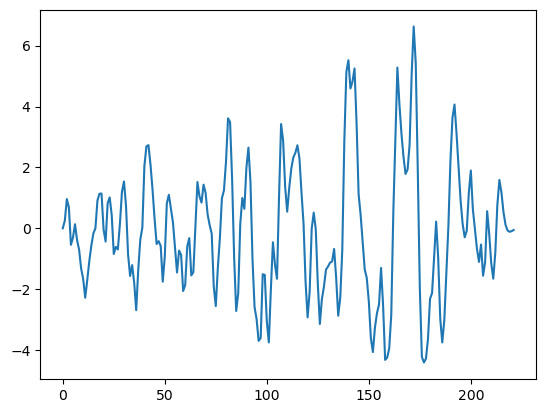

In [34]:
import matplotlib.pyplot as plt
plt.plot(pupil_reg[0])

In [ ]:
all_design_matrices = []
for run in range(1, runs+1):
    events = pd.DataFrame({'trial_type': conditions_all[run-1], 'onset': onsets_all[run-1], 'duration': 0})
    dm = make_first_level_design_matrix(frame_times=frametimes, events=events,add_regs=pd.concat([pd.DataFrame(pupil_all[run-1][0], columns=['pupil']),regressors_all[run-1]], axis=1), add_reg_names = ['pupil']+regressors_all[0].iloc[:,:-1].columns.values.tolist(), hrf_model='spm')
    all_design_matrices.append(dm)

<Axes: label='conditions', ylabel='scan number'>

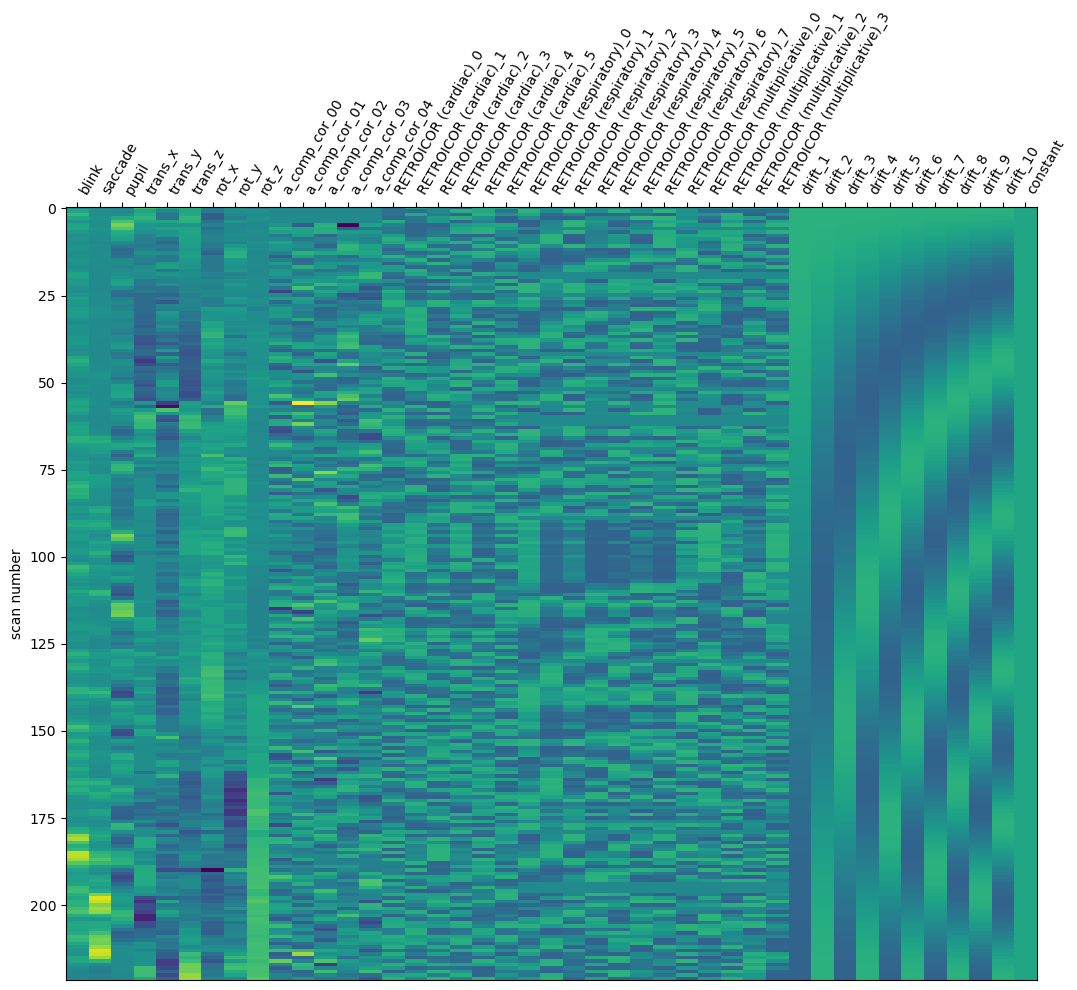

In [35]:
from nilearn.plotting import plot_design_matrix
plot_design_matrix(all_design_matrices[1])

In [36]:
from nilearn.glm.first_level import FirstLevelModel

fmri_glm = FirstLevelModel(
    #t_r=2.3,
    #slice_time_ref=0.5,
    mask_img="/mnt/d/multlearn-sns/SPM/mask_ICV.nii",
    #smoothing_fwhm=6,
    #minimize_memory=True,
)

fmri_glm_multirun = fmri_glm.fit(data, design_matrices=all_design_matrices)

/home/ella/anaconda3/envs/multlearn-decoding/lib/python3.11/site-packages/nilearn/maskers/nifti_masker.py:108: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(
/home/ella/anaconda3/envs/multlearn-decoding/lib/python3.11/site-packages/nilearn/maskers/nifti_masker.py:108: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(
/home/ella/anaconda3/envs/multlearn-decoding/lib/python3.11/site-packages/nilearn/maskers/nifti_masker.py:108: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a tar

: 

In [24]:
contrast_pupil = np.array([[1 if 'pupil' in col else 0 for col in all_design_matrices[0].columns]])
contrast_blinks = np.array([[1 if 'blink' in col else 0 for col in all_design_matrices[0].columns]])
contrast_saccades = np.array([[1 if 'saccade' in col else 0 for col in all_design_matrices[0].columns]])
print(contrast_pupil, contrast_blinks, contrast_saccades)
z_map_pupil = fmri_glm_multirun.compute_contrast(contrast_pupil, output_type='z_score')
z_map_blinks = fmri_glm_multirun.compute_contrast(contrast_blinks, output_type='z_score')
z_map_saccades = fmri_glm_multirun.compute_contrast(contrast_saccades, output_type='z_score')

[[0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0]] [[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0]] [[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0]]


/home/ella/anaconda3/envs/multlearn-decoding/lib/python3.11/site-packages/nilearn/glm/first_level/first_level.py:799: UserWarning: One contrast given, assuming it for all 6 runs
  warn(f"One contrast given, assuming it for all {int(n_runs)} runs")


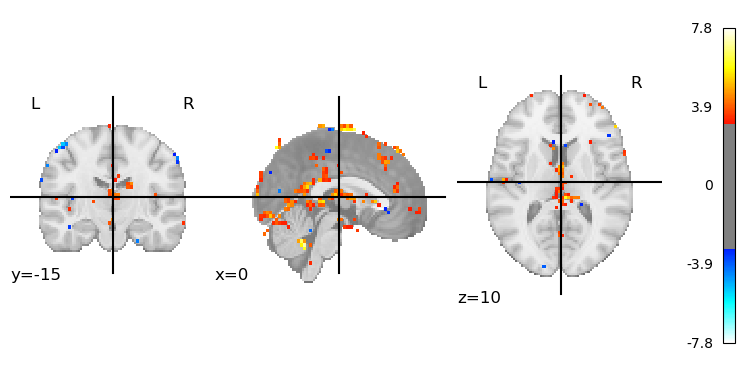

In [28]:
from nilearn import plotting
plotting.plot_stat_map(
    z_map_pupil,
    threshold=3.1,
    output_file=np.join(bids_folder, "derivatives", "pupil_preproc", f"sub-{subject:02d}", "plots", "pupil.png"),
)

plotting.show()

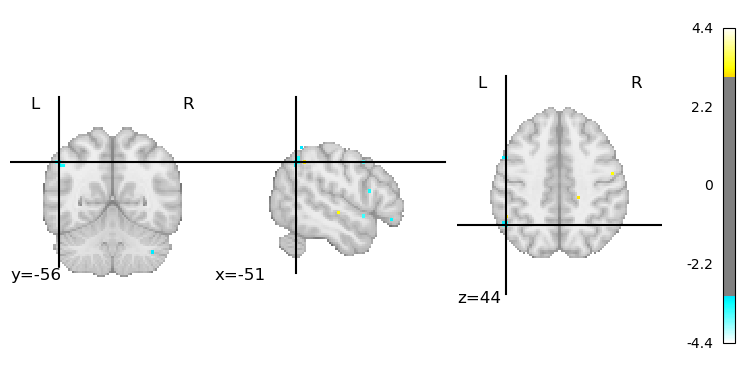

In [29]:
plotting.plot_stat_map(
    z_map_blinks,
    threshold=3.1,
)

plotting.show()

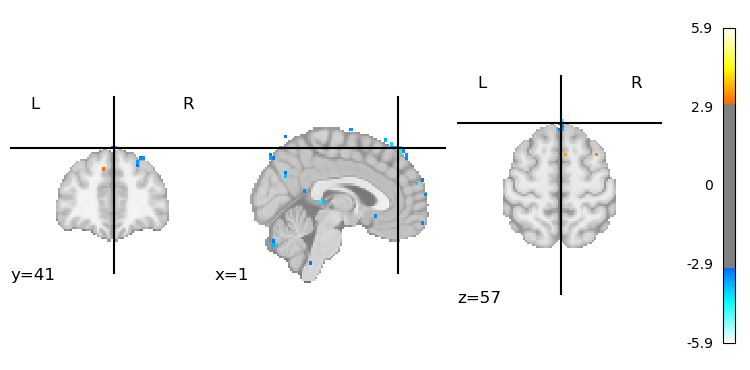

In [30]:
plotting.plot_stat_map(
    z_map_saccades,
    threshold=3.1,
)

plotting.show()